# Micro Creator NLP Analysis Notebook
This notebook is built for **the NLP analysis** of the project.

It covers:
1. Data loading and validation  
2. Text cleaning  
3. Group comparison: **High vs Low like-rate videos**  
4. **VADER sentiment analysis**  
5. **Keyword and bigram comparison**  
6. **LDA topic modeling**  
7. **Word clouds**  
8. Exporting report-ready tables and figures  

**Important:** Put this notebook in the **same folder** as:
- `micro_creator_success_patterns_detail.csv`
- `micro_creator_insights.csv`
- `Metrics meaning.docx`

## 1. Setup
This cell imports the packages and creates an output folder for figures and tables.

In [1]:
!pip install wordcloud

In [2]:
import os
import re
import math
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from wordcloud import WordCloud

warnings.filterwarnings("ignore")

OUTPUT_DIR = "nlp_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder ready:", OUTPUT_DIR)

Output folder ready: nlp_outputs


## 2. Load the data
This project-ready file already contains:
- only **micro creators**
- a `like_rate_group` column with **High** and **Low**
- text fields such as title, description, tags, and top comments

In [3]:
df = pd.read_csv("micro_creator_success_patterns_detail.csv")
summary_df = pd.read_csv("micro_creator_insights.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nlike_rate_group counts:")
print(df["like_rate_group"].value_counts(dropna=False))

display(df.head(3))
display(summary_df)

Shape: (1090, 43)

Columns:
['video_id', 'video_title', 'description', 'tags', 'category_id', 'published_at', 'channel_id', 'channel_title', 'view_count', 'like_count', 'comment_count', 'duration', 'subscriber_count', 'hashtags_from_title', 'hashtags_from_desc', 'hashtag_count', 'top_comments_text', 'comment_like_count', 'like_rate', 'log_view_count', 'log_like_count', 'log_comment_count', 'log_subscriber_count', 'scaled_log_view_count', 'scaled_log_like_count', 'scaled_log_comment_count', 'scaled_log_subscriber_count', 'scaled_like_rate', 'scaled_hashtag_count', 'like_rate_group', 'post_hour', 'post_day', 'desc_length', 'has_question_mark', 'has_exclamation', 'title_hashtag_count', 'desc_hashtag_count', 'is_vlog', 'is_short', 'is_daily_life', 'is_first_video', 'duration_seconds', 'duration_bucket']

like_rate_group counts:
like_rate_group
Low     545
High    545
Name: count, dtype: int64


,video_id,video_title,description,tags,category_id,published_at,channel_id,channel_title,view_count,like_count,...,has_question_mark,has_exclamation,title_hashtag_count,desc_hashtag_count,is_vlog,is_short,is_daily_life,is_first_video,duration_seconds,duration_bucket
0,ZbxxbwKU89c,mt15 ... #viralvideo #terending #mydreambike #...,mt15 ... #viralvideo #terending #mydreambike #...,NaN,22,2026-04-14 11:53:19+00:00,UCk9FIlO0LEuNloLxTERQH4Q,Akash Kumar@,624,8,...,0,0,6,8,1,0,0,1,18.0,<=1 min
1,2ThqSZnSXn4,My First Vlog #youtubeshorts #shorts #villagel...,My First Vlog #youtubeshorts #shorts #villagel...,dasharathprajapativlog96 ||| dasharathprajapat...,22,2026-04-14 11:35:00+00:00,UCQO3oW5YH7jx9KyemPt68Wg,Dasharath Prajapati Vlogs 96,412,5,...,0,0,4,4,1,1,0,1,57.0,<=1 min
2,xJn7zCZeSxU,My first vlog please support #viral vlog 1.2 M...,आज के इस व्लॉग में मैं [जगह का नाम/गतिविधि] की...,NaN,22,2026-04-14 11:12:18+00:00,UC1wqW1cOllIoqgAVMFpJhSA,Ajit Official,58,7,...,0,1,1,2,1,0,0,1,10.0,<=1 min


,metric,high_value,low_value,difference
0,like_rate,0.1033,0.0047,0.0986
1,view_count,2410.5780,12554.4716,-10143.8936
2,like_count,84.5596,15.4459,69.1138
3,comment_count,10.5101,2.5927,7.9174
4,duration_seconds,910.0624,292.4798,617.5826
5,post_hour,10.9046,10.5486,0.3560
6,desc_length,391.6587,336.4055,55.2532
7,hashtag_count,10.0606,11.4459,-1.3853
8,title_hashtag_count,2.9229,3.5229,-0.6000
9,desc_hashtag_count,7.1376,7.9229,-0.7853


## 3. Quick validation
This checks whether the columns needed for NLP are present.

In [4]:
required_cols = ["video_title", "description", "top_comments_text", "like_rate_group", "like_rate"]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")
else:
    print("All required NLP columns are present.")

All required NLP columns are present.


## 4. Build the text fields
We will build three versions:
- `text_title_desc`: title + description  
- `text_full`: title + description + top comments  
- `text_comments_only`: comments only  

For this project:
- **VADER** will use `text_full`
- **LDA** will mainly use `text_title_desc`
- **Word clouds** can use `text_full`

In [5]:
def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x)

df["video_title"] = df["video_title"].apply(safe_text)
df["description"] = df["description"].apply(safe_text)
df["top_comments_text"] = df["top_comments_text"].apply(safe_text)
df["tags"] = df["tags"].apply(safe_text) if "tags" in df.columns else ""

df["text_title_desc"] = (
    df["video_title"].str.strip() + " " + df["description"].str.strip()
).str.strip()

df["text_full"] = (
    df["video_title"].str.strip() + " " + 
    df["description"].str.strip() + " " +
    df["top_comments_text"].str.strip()
).str.strip()

df["text_comments_only"] = df["top_comments_text"].str.strip()

display(df[["video_title", "description", "top_comments_text", "text_full"]].head(3))

,video_title,description,top_comments_text,text_full
0,mt15 ... #viralvideo #terending #mydreambike #...,mt15 ... #viralvideo #terending #mydreambike #...,,mt15 ... #viralvideo #terending #mydreambike #...
1,My First Vlog #youtubeshorts #shorts #villagel...,My First Vlog #youtubeshorts #shorts #villagel...,,My First Vlog #youtubeshorts #shorts #villagel...
2,My first vlog please support #viral vlog 1.2 M...,आज के इस व्लॉग में मैं [जगह का नाम/गतिविधि] की...,,My first vlog please support #viral vlog 1.2 M...


## 5. Clean the text
This function:
- lowercases text
- removes URLs
- removes emojis and most symbols
- removes hashtags `#`
- keeps words and spaces
- removes extra whitespace

In [6]:
def clean_text(text):
    text = safe_text(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.replace("|||", " ")
    text = text.replace("#", " ")
    text = text.replace("@", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\b\w\b", " ", text)   # remove single letters
    text = re.sub(r"\s+", " ", text).strip()
    return text

for col in ["text_title_desc", "text_full", "text_comments_only"]:
    df[f"clean_{col}"] = df[col].apply(clean_text)

display(df[["text_full", "clean_text_full"]].head(3))

,text_full,clean_text_full
0,mt15 ... #viralvideo #terending #mydreambike #...,mt viralvideo terending mydreambike bikeloverm...
1,My First Vlog #youtubeshorts #shorts #villagel...,my first vlog youtubeshorts shorts villagelife...
2,My first vlog please support #viral vlog 1.2 M...,my first vlog please support viral vlog week a...


## 6. Basic text coverage
This helps you understand how much text is actually available for each field.

In [7]:
coverage = pd.DataFrame({
    "field": ["video_title", "description", "top_comments_text", "text_full"],
    "non_empty_rows": [
        (df["video_title"].str.len() > 0).sum(),
        (df["description"].str.len() > 0).sum(),
        (df["top_comments_text"].str.len() > 0).sum(),
        (df["text_full"].str.len() > 0).sum()
    ]
})
coverage["pct_of_dataset"] = (coverage["non_empty_rows"] / len(df)).round(4)

display(coverage)
coverage.to_csv(os.path.join(OUTPUT_DIR, "text_coverage_summary.csv"), index=False)

,field,non_empty_rows,pct_of_dataset
0,video_title,1090,1.0000
1,description,623,0.5716
2,top_comments_text,404,0.3706
3,text_full,1090,1.0000


## 7. Split High vs Low groups
Your teammate already created a balanced split:
- **High**: 545 videos
- **Low**: 545 videos

In [8]:
high_df = df[df["like_rate_group"].str.upper() == "HIGH"].copy()
low_df = df[df["like_rate_group"].str.upper() == "LOW"].copy()

print("High group:", high_df.shape)
print("Low group:", low_df.shape)

High group: (545, 49)
Low group: (545, 49)


## 8. VADER sentiment analysis
We use NLTK's VADER to compute:
- negative
- neutral
- positive
- compound

If the VADER lexicon is missing on your computer, the code below downloads it once.

In [9]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    _ = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

def vader_scores(text):
    if not safe_text(text).strip():
        return {"neg": np.nan, "neu": np.nan, "pos": np.nan, "compound": np.nan}
    return sia.polarity_scores(text)

sentiment_df = df["clean_text_full"].apply(vader_scores).apply(pd.Series)
sentiment_df.columns = [f"sent_{c}" for c in sentiment_df.columns]

df = pd.concat([df, sentiment_df], axis=1)

display(df[["like_rate_group", "clean_text_full", "sent_neg", "sent_neu", "sent_pos", "sent_compound"]].head(3))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/kylinhwang/nltk_data...


,like_rate_group,clean_text_full,sent_neg,sent_neu,sent_pos,sent_compound
0,Low,mt viralvideo terending mydreambike bikeloverm...,0.0,1.000,0.000,0.0000
1,Low,my first vlog youtubeshorts shorts villagelife...,0.0,1.000,0.000,0.0000
2,High,my first vlog please support viral vlog week a...,0.0,0.688,0.312,0.6124


## 9. Sentiment comparison: High vs Low
This is one of your report-ready outputs.

,like_rate_group,sent_neg,sent_neu,sent_pos,sent_compound
0,High,0.0206,0.8388,0.1406,0.4644
1,Low,0.0142,0.8525,0.1333,0.4083


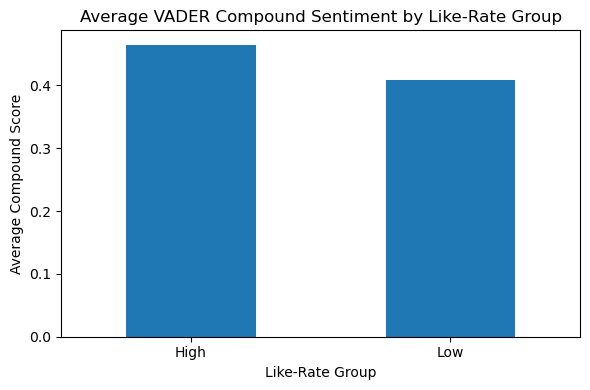

In [10]:
sentiment_summary = (
    df.groupby("like_rate_group")[["sent_neg", "sent_neu", "sent_pos", "sent_compound"]]
      .mean()
      .round(4)
      .reset_index()
)

display(sentiment_summary)
sentiment_summary.to_csv(os.path.join(OUTPUT_DIR, "sentiment_summary_by_group.csv"), index=False)

# Plot compound sentiment
plot_df = sentiment_summary.set_index("like_rate_group")["sent_compound"]

plt.figure(figsize=(6, 4))
plot_df.plot(kind="bar")
plt.title("Average VADER Compound Sentiment by Like-Rate Group")
plt.xlabel("Like-Rate Group")
plt.ylabel("Average Compound Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentiment_compound_bar.png"), dpi=300, bbox_inches="tight")
plt.show()

## 10. Word frequency comparison
We compare the most common words in:
- High group
- Low group

We use CountVectorizer with English stop words removed.

In [11]:
vectorizer_uni = CountVectorizer(stop_words="english", min_df=5)
X_uni = vectorizer_uni.fit_transform(df["clean_text_full"])

word_counts = pd.DataFrame(
    X_uni.toarray(),
    columns=vectorizer_uni.get_feature_names_out()
)
word_counts["like_rate_group"] = df["like_rate_group"].values

high_word_means = word_counts[word_counts["like_rate_group"] == "High"].drop(columns="like_rate_group").mean()
low_word_means = word_counts[word_counts["like_rate_group"] == "Low"].drop(columns="like_rate_group").mean()

word_compare = pd.DataFrame({
    "word": high_word_means.index,
    "high_mean_freq": high_word_means.values,
    "low_mean_freq": low_word_means.reindex(high_word_means.index).values
})

word_compare["difference"] = word_compare["high_mean_freq"] - word_compare["low_mean_freq"]
word_compare = word_compare.sort_values("difference", ascending=False)

top_high_words = word_compare.head(25).copy()
top_low_words = word_compare.sort_values("difference", ascending=True).head(25).copy()

display(top_high_words)
display(top_low_words)

top_high_words.to_csv(os.path.join(OUTPUT_DIR, "top_words_more_common_in_high.csv"), index=False)
top_low_words.to_csv(os.path.join(OUTPUT_DIR, "top_words_more_common_in_low.csv"), index=False)

,word,high_mean_freq,low_mean_freq,difference
489,jee,0.748624,0.095413,0.653211
1029,video,0.954128,0.638532,0.315596
144,channel,0.653211,0.365138,0.288073
1100,youtube,0.798165,0.524771,0.273394
454,ideas,0.218349,0.029358,0.188991
456,iit,0.177982,0.011009,0.166972
1069,week,0.222018,0.078899,0.143119
576,love,0.216514,0.093578,0.122936
498,just,0.150459,0.047706,0.102752
46,aspirant,0.170642,0.082569,0.088073


,word,high_mean_freq,low_mean_freq,difference
1046,vlog,2.078899,2.917431,-0.838532
1037,viral,0.306422,0.644037,-0.337615
620,mini,0.216514,0.543119,-0.326606
903,study,0.911927,1.141284,-0.229358
463,india,0.113761,0.277064,-0.163303
876,ssc,0.007339,0.168807,-0.161468
342,food,0.143119,0.300917,-0.157798
156,class,0.177982,0.313761,-0.135780
1018,upsc,0.003670,0.137615,-0.133945
16,aesthetic,0.200000,0.330275,-0.130275


## 11. Plot top differentiating words
These two charts are useful for slides.

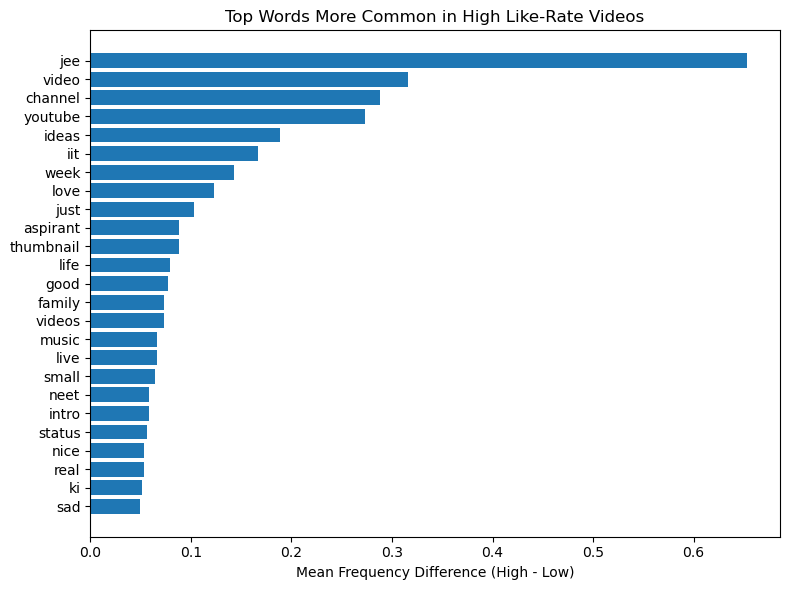

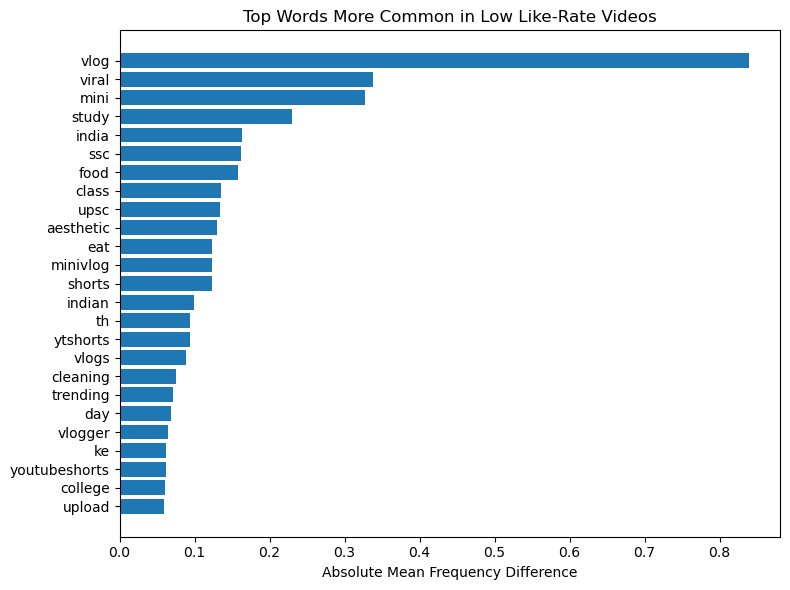

In [12]:
plt.figure(figsize=(8, 6))
plt.barh(top_high_words["word"][::-1], top_high_words["difference"][::-1])
plt.title("Top Words More Common in High Like-Rate Videos")
plt.xlabel("Mean Frequency Difference (High - Low)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_high_words_bar.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(top_low_words["word"][::-1], np.abs(top_low_words["difference"][::-1]))
plt.title("Top Words More Common in Low Like-Rate Videos")
plt.xlabel("Absolute Mean Frequency Difference")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_low_words_bar.png"), dpi=300, bbox_inches="tight")
plt.show()

## 12. Bigram comparison
Bigrams are two-word phrases such as:
- `daily vlog`
- `first vlog`
- `how to`

This often gives stronger insight than single words.

In [13]:
vectorizer_bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), min_df=3)
X_bi = vectorizer_bi.fit_transform(df["clean_text_full"])

bigram_counts = pd.DataFrame(
    X_bi.toarray(),
    columns=vectorizer_bi.get_feature_names_out()
)
bigram_counts["like_rate_group"] = df["like_rate_group"].values

high_bi_means = bigram_counts[bigram_counts["like_rate_group"] == "High"].drop(columns="like_rate_group").mean()
low_bi_means = bigram_counts[bigram_counts["like_rate_group"] == "Low"].drop(columns="like_rate_group").mean()

bigram_compare = pd.DataFrame({
    "bigram": high_bi_means.index,
    "high_mean_freq": high_bi_means.values,
    "low_mean_freq": low_bi_means.reindex(high_bi_means.index).values
})

bigram_compare["difference"] = bigram_compare["high_mean_freq"] - bigram_compare["low_mean_freq"]

top_high_bigrams = bigram_compare.sort_values("difference", ascending=False).head(20)
top_low_bigrams = bigram_compare.sort_values("difference", ascending=True).head(20)

display(top_high_bigrams)
display(top_low_bigrams)

top_high_bigrams.to_csv(os.path.join(OUTPUT_DIR, "top_bigrams_more_common_in_high.csv"), index=False)
top_low_bigrams.to_csv(os.path.join(OUTPUT_DIR, "top_bigrams_more_common_in_low.csv"), index=False)

,bigram,high_mean_freq,low_mean_freq,difference
1348,vlog jee,0.216514,0.007339,0.209174
1486,youtube channel,0.278899,0.069725,0.209174
512,jee aspirant,0.106422,0.007339,0.099083
1460,week life,0.106422,0.047706,0.058716
477,iit jee,0.062385,0.007339,0.055046
626,life jee,0.062385,0.007339,0.055046
473,ideas youtube,0.053211,0.000000,0.053211
112,channel intro,0.111927,0.066055,0.045872
991,small creator,0.080734,0.034862,0.045872
364,funny video,0.047706,0.003670,0.044037


,bigram,high_mean_freq,low_mean_freq,difference
708,mini vlog,0.170642,0.394495,-0.223853
1076,study vlog,0.322936,0.515596,-0.192661
290,eat day,0.075229,0.190826,-0.115596
709,mini vlogs,0.011009,0.113761,-0.102752
1413,vlog viral,0.034862,0.132110,-0.097248
1287,viral vlog,0.009174,0.082569,-0.073394
1415,vlog vlog,0.042202,0.100917,-0.058716
145,class study,0.029358,0.086239,-0.056881
1249,video viral,0.009174,0.060550,-0.051376
689,make mini,0.001835,0.049541,-0.047706


## 13. Word clouds
These are visual support tools for presentation slides.

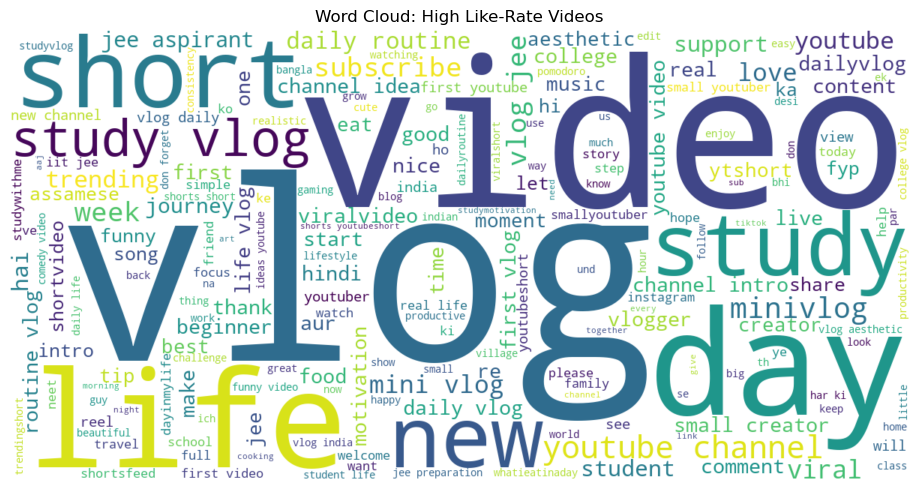

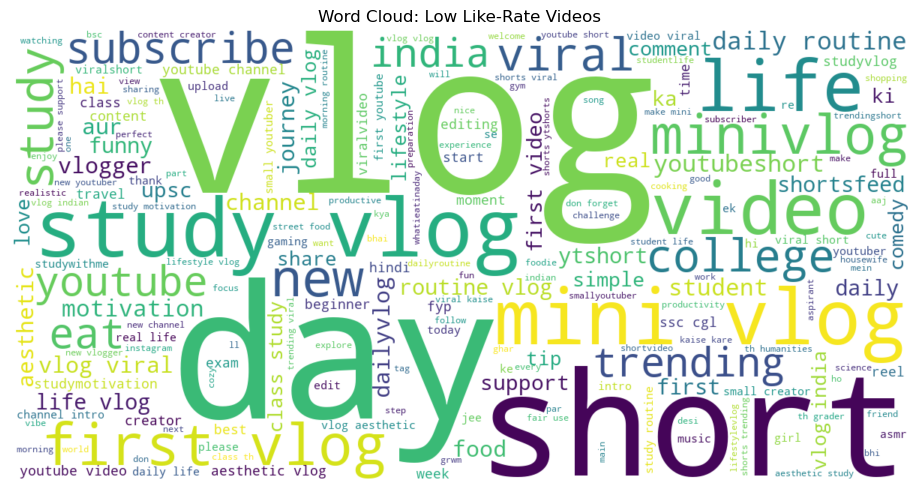

In [14]:
high_text = " ".join(high_df["clean_text_full"].dropna().tolist())
low_text = " ".join(low_df["clean_text_full"].dropna().tolist())

wc_high = WordCloud(width=1200, height=600, background_color="white").generate(high_text if high_text.strip() else "empty")
wc_low = WordCloud(width=1200, height=600, background_color="white").generate(low_text if low_text.strip() else "empty")

plt.figure(figsize=(12, 5))
plt.imshow(wc_high, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: High Like-Rate Videos")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "wordcloud_high.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(wc_low, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Low Like-Rate Videos")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "wordcloud_low.png"), dpi=300, bbox_inches="tight")
plt.show()

## 14. LDA topic modeling
We will run LDA separately for:
- High group
- Low group

This is easier to interpret for your project because your real goal is:
**What topics appear in successful videos vs unsuccessful videos?**

In [15]:
def run_lda_topic_model(text_series, n_topics=5, min_df=5, max_df=0.9, n_top_words=12, random_state=42):
    vectorizer = CountVectorizer(stop_words="english", min_df=min_df, max_df=max_df)
    X = vectorizer.fit_transform(text_series)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=random_state,
        learning_method="batch"
    )
    lda.fit(X)

    feature_names = vectorizer.get_feature_names_out()
    topics = []

    for topic_idx, topic in enumerate(lda.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_features_ind]
        topics.append({
            "topic_id": topic_idx + 1,
            "top_words": ", ".join(top_words)
        })

    doc_topic = lda.transform(X)
    doc_topic_df = pd.DataFrame(doc_topic, columns=[f"topic_{i+1}" for i in range(n_topics)])
    doc_topic_df["dominant_topic"] = doc_topic_df.idxmax(axis=1)

    topics_df = pd.DataFrame(topics)
    topic_distribution = doc_topic_df["dominant_topic"].value_counts(normalize=True).sort_index().reset_index()
    topic_distribution.columns = ["dominant_topic", "pct_of_docs"]

    return {
        "vectorizer": vectorizer,
        "lda_model": lda,
        "topics_df": topics_df,
        "doc_topic_df": doc_topic_df,
        "topic_distribution": topic_distribution,
        "X": X
    }

### 14A. LDA for High like-rate videos

In [16]:
lda_high = run_lda_topic_model(high_df["clean_text_title_desc"], n_topics=5)
display(lda_high["topics_df"])
display(lda_high["topic_distribution"])

lda_high["topics_df"].to_csv(os.path.join(OUTPUT_DIR, "lda_topics_high.csv"), index=False)
lda_high["topic_distribution"].to_csv(os.path.join(OUTPUT_DIR, "lda_topic_distribution_high.csv"), index=False)

,topic_id,top_words
0,1,"vlog, daily, life, routine, college, minivlog,..."
1,2,"video, vlog, shorts, youtube, new, viral, crea..."
2,3,"channel, youtube, video, intro, ideas, new, li..."
3,4,"study, jee, vlog, life, day, aspirant, class, ..."
4,5,"day, life, vlog, week, food, aesthetic, eat, f..."


,dominant_topic,pct_of_docs
0,topic_1,0.209174
1,topic_2,0.245872
2,topic_3,0.214679
3,topic_4,0.122936
4,topic_5,0.207339


### 14B. LDA for Low like-rate videos

In [17]:
lda_low = run_lda_topic_model(low_df["clean_text_title_desc"], n_topics=5)
display(lda_low["topics_df"])
display(lda_low["topic_distribution"])

lda_low["topics_df"].to_csv(os.path.join(OUTPUT_DIR, "lda_topics_low.csv"), index=False)
lda_low["topic_distribution"].to_csv(os.path.join(OUTPUT_DIR, "lda_topic_distribution_low.csv"), index=False)

,topic_id,top_words
0,1,"vlog, hai, small, aur, support, ke, youtuber, ..."
1,2,"study, vlog, class, th, aesthetic, motivation,..."
2,3,"video, youtube, viral, new, channel, intro, sh..."
3,4,"life, routine, daily, like, channel, subscribe..."
4,5,"vlog, mini, day, shorts, minivlog, life, viral..."


,dominant_topic,pct_of_docs
0,topic_1,0.168807
1,topic_2,0.132110
2,topic_3,0.165138
3,topic_4,0.154128
4,topic_5,0.379817


## 15. Visualize topic distributions

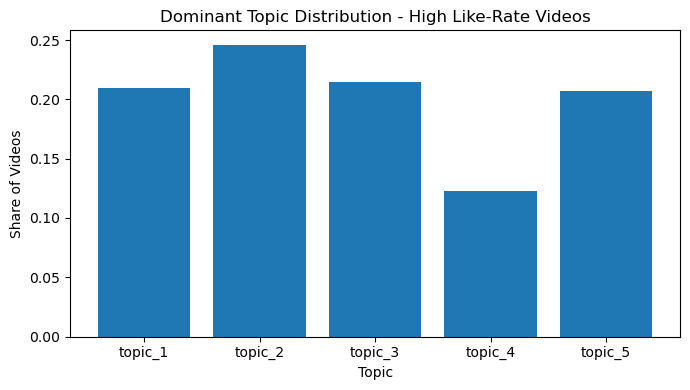

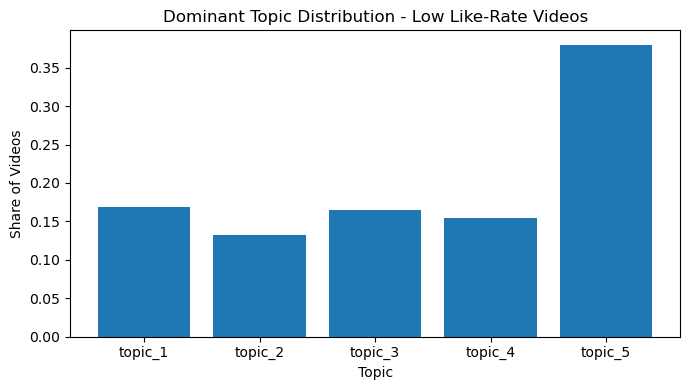

In [18]:
high_topic_plot = lda_high["topic_distribution"].copy()
low_topic_plot = lda_low["topic_distribution"].copy()

plt.figure(figsize=(7, 4))
plt.bar(high_topic_plot["dominant_topic"], high_topic_plot["pct_of_docs"])
plt.title("Dominant Topic Distribution - High Like-Rate Videos")
plt.xlabel("Topic")
plt.ylabel("Share of Videos")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lda_distribution_high.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(low_topic_plot["dominant_topic"], low_topic_plot["pct_of_docs"])
plt.title("Dominant Topic Distribution - Low Like-Rate Videos")
plt.xlabel("Topic")
plt.ylabel("Share of Videos")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lda_distribution_low.png"), dpi=300, bbox_inches="tight")
plt.show()

## 16. Add dominant topics back to the original data
This helps you inspect real videos behind each topic.

In [19]:
high_topic_assign = lda_high["doc_topic_df"][["dominant_topic"]].copy()
high_topic_assign.index = high_df.index

low_topic_assign = lda_low["doc_topic_df"][["dominant_topic"]].copy()
low_topic_assign.index = low_df.index

df["dominant_topic"] = np.nan
df.loc[high_topic_assign.index, "dominant_topic"] = high_topic_assign["dominant_topic"]
df.loc[low_topic_assign.index, "dominant_topic"] = low_topic_assign["dominant_topic"]

display(df[["video_title", "like_rate_group", "dominant_topic"]].head())

,video_title,like_rate_group,dominant_topic
0,mt15 ... #viralvideo #terending #mydreambike #...,Low,topic_5
1,My First Vlog #youtubeshorts #shorts #villagel...,Low,topic_5
2,My first vlog please support #viral vlog 1.2 M...,High,topic_5
3,My First Vlog | Aaj Se New Journey Start! #vlo...,Low,topic_5
4,ALHAMDULILLAH MY FIRST VLOG #YOUTUBE #VIRALVID...,High,topic_2


## 17. Export example videos for each topic
This is extremely useful for manual interpretation in the report.
You should read 5 to 10 real examples from each topic and then assign a human label, such as:
- Beginner how-to
- Daily lifestyle
- Personal vlog
- Short-form trend content
- Motivational / emotional content

In [20]:
topic_examples = (
    df[["video_title", "description", "like_rate_group", "like_rate", "dominant_topic"]]
      .dropna(subset=["dominant_topic"])
      .sort_values(["like_rate_group", "dominant_topic", "like_rate"], ascending=[True, True, False])
)

topic_examples.to_csv(os.path.join(OUTPUT_DIR, "topic_examples_for_manual_labeling.csv"), index=False)
display(topic_examples.head(20))

,video_title,description,like_rate_group,like_rate,dominant_topic
439,Islamic Cartoon Channel Intro | New Moral Stor...,Assalamualaikum Dosto Hum ne aik naya Islamic ...,High,1.000000,topic_1
659,Daily routine Vlog #viralvideo #cooking #clean...,dailyroutine #cooking #peaceful #tahajjuddua #...,High,1.000000,topic_1
708,My Daily Life Vlog | Full Day Routine #lifeisb...,Hey guys Welcome back to my channel! In this v...,High,1.000000,topic_1
733,Enjoying my Morning at Balcony | Daily routine...,"“Real Daily Routine of a Woman | Home, Gym & C...",High,1.000000,topic_1
675,Daily routine vlog/ Karly bar k recipe/ Karly ...,,High,0.750000,topic_1
730,Dupamine Dance | Morning Routine ️.| Daily rou...,"“Real Daily Routine of a Woman | Home, Gym & C...",High,0.500000,topic_1
690,आम्ही कुठे गेलो होतो बघा ||daily routine vlog ...,,High,0.363636,topic_1
40,MY FIRST VLOG: एक ऐतिहासिक रहस्य का सफर! ️‍️ |...,Description Namaste doston! Swagat hai mere pe...,High,0.300000,topic_1
695,“Kya Main Yeh Roz Karta Hoon? ” || Daily Routi...,Kya Main Yeh Roz Karta Hoon? Mera real daily r...,High,0.285714,topic_1
328,A Day With My Friends | Vlog | What Happen Wit...,Aaj ka vlog ek simple din ko special bana deta...,High,0.272727,topic_1


## 18. Build a report-ready insight table
This table gives you a clean structure for your report or presentation.
You will manually fill in the human interpretation after reviewing the LDA topics.

In [21]:
insight_table = pd.DataFrame({
    "analysis_block": [
        "Sentiment",
        "Keywords",
        "Bigrams",
        "LDA Topics",
        "Content Gap",
        "Viewer Pain Points",
        "Actionable Recommendation"
    ],
    "what_to_write": [
        "Compare average VADER compound scores between High and Low groups.",
        "List the words more common in high-performing videos and the words more common in low-performing videos.",
        "Highlight high-performing phrases such as routine-oriented, tutorial-oriented, or relatable phrases if they appear.",
        "Translate each LDA topic into a human-readable content theme.",
        "Explain what successful videos provide that weaker videos do not.",
        "Infer what audience need is being met, such as relatability, practical guidance, identity, or entertainment.",
        "Recommend what new creators should talk about, how they should frame titles/descriptions, and what content angles seem under-served."
    ]
})

display(insight_table)
insight_table.to_csv(os.path.join(OUTPUT_DIR, "nlp_evidence_summary.csv"), index=False)

,analysis_block,what_to_write
0,Sentiment,Compare average VADER compound scores between ...
1,Keywords,List the words more common in high-performing ...
2,Bigrams,Highlight high-performing phrases such as rout...
3,LDA Topics,Translate each LDA topic into a human-readable...
4,Content Gap,Explain what successful videos provide that we...
5,Viewer Pain Points,"Infer what audience need is being met, such as..."
6,Actionable Recommendation,"Recommend what new creators should talk about,..."


## 19. Suggested writing template for your report
Use this after you inspect your actual results.

**NLP Methodology**  
We applied Natural Language Processing to compare high and low like-rate videos among micro creators. Text was constructed from video titles, descriptions, and top comments, then cleaned through lowercasing, symbol removal, and whitespace normalization. We used VADER to evaluate sentiment differences and LDA to identify latent content themes across performance groups.

**Sentiment Findings**  
High-performing and low-performing videos showed different language tone patterns. By comparing average VADER scores, we examined whether more successful videos used more positive, engaging, or emotionally expressive wording.

**Keyword and Topic Findings**  
Word-frequency, bigram, and topic-modeling results were used to identify systematic textual differences between high-performing and low-performing content. These differences help explain what themes, phrasing styles, and content promises are more common in successful novice videos.

**Content Gap Discovery**  
The LDA topics were translated into viewer pain points and content needs. Instead of treating topics as only technical outputs, we interpreted them as signs of unmet audience demand. This allowed us to identify content gaps that new creators can target more effectively.

## 20. Final deliverables from this notebook
After running all cells, your `nlp_outputs` folder will contain:
- sentiment summary CSV
- top words CSVs
- top bigrams CSVs
- LDA topic CSVs
- example videos for manual labeling
- PNG charts for slides
- word clouds
- a writing guide for your report

At that point, your next step is:
1. Read the top words and bigrams  
2. Read the LDA topic examples  
3. Rename each topic in plain English  
4. Turn those findings into **viewer pain points + content recommendations**